In [1]:
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
from Bio import SeqIO, SearchIO, Entrez
import seaborn as sns
import pandas as pd
import os, glob, math, re, gzip, skbio, time
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import warnings
from Bio import Entrez
#warnings.filterwarnings('ignore')
Entrez.email = "ajaffe@stanford.edu"

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def scaffold(gene):
    if gene != "None":
        try: return re.search("(.+?)_[0-9]+$", gene).group(1)
        except: print(gene)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
import sys
sys.path.insert(0, '/home/users/ajaffe/notebooks/modules/')
import parse

In [4]:
rootdir = "/scratch/users/ajaffe/rubisco-div/"
cmdir(rootdir)

## pairwise sequence comparisons

In [10]:
cmdir(rootdir + "pairwise")

### merge

In [11]:
clust65 = pd.read_csv(rootdir + "tables/full_tree_clustering.tsv", sep="\t")
clust65 = pd.merge(clust65, full_md[["cluster65", "final_form_assignment"]],
                   how="left", left_on="cluster", right_on="cluster65").fillna("None")
clust65.shape

(86798, 9)

In [12]:
clust90 = pd.read_csv(rootdir + "tables/subtree_clustering.tsv", sep="\t")
clust90 = pd.merge(clust90, sub_md[["cluster90", "final_form_assignment"]],
                   how="left", left_on="cluster", right_on="cluster90").fillna("None")
clust90sub = clust90[["member", "final_form_assignment"]]
clust90sub.columns = ["member", "subform_assignment"]

In [13]:
merged = clust65.merge(clust90sub, how="left", on="member").fillna("None")
merged["final_subform_assignment"] = merged.apply(lambda x: "None" \
    if x["final_form_assignment"]=="IIIC" else x["subform_assignment"], axis=1)

# drop PDB sequences
merged = merged[~merged["member"].str.match("NRX_[1-9][A-Z]*_A")]
# add back sequence and subset
sequence_info = pd.read_csv(rootdir + "prelim_sequence_info.csv")
merged = merged.merge(sequence_info[["header_clean", "sequence"]], 
                      how="left", left_on="member_brief", right_on="header_clean").fillna("None")
base = merged.drop_duplicates()[["member", "member_brief", "final_form_assignment", 
                                 "final_subform_assignment", "sequence"]]
base.head()

,member,member_brief,final_form_assignment,final_subform_assignment,sequence
0,WIN_MBI5465152.1,MBI5465152.1,IIIC,None,MDKHSFFTNNLAQTVADIRSLKIQGATEVARAGLKALLEIPDDKIN...
2,NRX_MBI5465152.1,MBI5465152.1,IIIC,None,MDKHSFFTNNLAQTVADIRSLKIQGATEVARAGLKALLEIPDDKIN...
4,NRX_MCL4382661.1,MCL4382661.1,IIIC,None,MDNLEKTIEEIKSLKIQGATNVAKAGLKVLQTLPTEKIPEAIEALL...
5,NRX_TSC54433.1,TSC54433.1,IIIC,None,MKRAKQEDEEKQTNMQSALETLLSLPEEQIPEAIQDLISTRPTEPL...
6,NRX_MBI4999172.1,MBI4999172.1,IIIC,None,MVKKNYPWIVSSRKYQVESIKGTTPYKSYLHLGEKVDPKIHIIADF...


In [14]:
base.to_csv(rootdir + "tables/curated_sequence_info.tsv", sep="\t", index=False)

### sample

In [15]:
import random

In [16]:
retained = []

for form in base["final_form_assignment"].unique():
    
    if form not in ["I", "UNK"]:
        
        table = base[base["final_form_assignment"]==form]
        sample = random.sample(table["member"].to_list(), min(len(table), 50))
        retained += sample

for subform in base["final_subform_assignment"].unique():
    
    if subform not in ["None", "UNK"]:
        
        table = base[base["final_subform_assignment"]==subform]
        sample = random.sample(table["member"].to_list(), min(len(table), 50))
        retained += sample
        
pwise = base[base["member"].isin(retained)].drop_duplicates("member")

### align and trim

In [17]:
with open(rootdir + "pairwise/sample.faa", "w") as out:
    for key, row in pwise.iterrows():
        out.write(">%s\n%s\n" %(row["member"], row["sequence"]))

In [34]:
aln = "mafft --thread 20 --reorder --auto %s > %s" %(rootdir + "pairwise/sample.faa",
                                           rootdir + "pairwise/sample.mafft")
print(aln)

for threshold in [0, 0.10, 0.60]: #[0, 0.05, 0.10, 0.15, 0.20, 0.25]:
    
    string = str(int(threshold*100))
    trim = "trimal -in %s -out %s -gt %.2f" %(rootdir + "pairwise/sample.mafft",
                                            rootdir + "pairwise/sample.trim" + string + ".mafft", threshold)
    print(trim)

mafft --thread 20 --reorder --auto /scratch/users/ajaffe/rubisco-div/pairwise/sample.faa > /scratch/users/ajaffe/rubisco-div/pairwise/sample.mafft
trimal -in /scratch/users/ajaffe/rubisco-div/pairwise/sample.mafft -out /scratch/users/ajaffe/rubisco-div/pairwise/sample.trim0.mafft -gt 0.00
trimal -in /scratch/users/ajaffe/rubisco-div/pairwise/sample.mafft -out /scratch/users/ajaffe/rubisco-div/pairwise/sample.trim10.mafft -gt 0.10
trimal -in /scratch/users/ajaffe/rubisco-div/pairwise/sample.mafft -out /scratch/users/ajaffe/rubisco-div/pairwise/sample.trim60.mafft -gt 0.60


### explore gappiness

In [18]:
records = [record for record in sfp(open(rootdir + "pairwise/sample.trim0.mafft"))]
aln_len = len(records[0][1])
print(aln_len)

1464


In [19]:
gap_percs = []

for position in range(0,aln_len):
    
    gaps = 0
    
    for record in records:
        if record[1][position] == "-":
            gaps +=1
    
    gap_percs.append(gaps/len(records)*100)

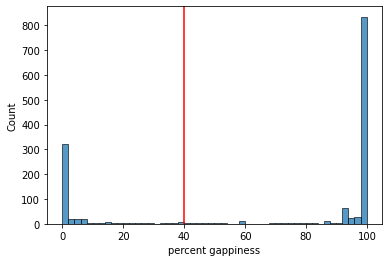

In [20]:
sns.histplot(gap_percs, stat="count", bins=50)
plt.xlabel("percent gappiness")
# -gt (1-[frac of seqs with gap allowed])
plt.axvline(40,c='red')
plt.show()

### calculate identities

In [21]:
from itertools import combinations

In [22]:
for aln in glob.glob(rootdir + "pairwise/sample.trim*mafft"):
    
    print(aln)
    records = [record for record in sfp(open(aln))]
    info = defaultdict(list)

    for sq, seq_pair in enumerate(combinations(records, 2)):

        info["seq1"].append(seq_pair[0][0])
        info["seq2"].append(seq_pair[1][0])

        ids_no_gaps = 0
        ids_w_gaps = 0
        pos_no_gaps = 0
        pos_w_gaps = 0

        for i in range(0, len(records[0][1])):

            seq_1_base = seq_pair[0][1][i]
            seq_2_base = seq_pair[1][1][i]

            if (seq_1_base != '-') or (seq_2_base != '-'):

                pos_no_gaps += 1

                if seq_1_base == seq_2_base:
                    ids_no_gaps +=1

            if seq_1_base == seq_2_base:
                ids_w_gaps +=1
            pos_w_gaps +=1

        info["pid_wgaps"].append(float(ids_w_gaps/pos_w_gaps)*100)
        info["aa_compared_wgaps"].append(pos_w_gaps)
        info["pid_nogaps"].append(float(ids_no_gaps/pos_no_gaps)*100)
        info["aa_compared_nogaps"].append(pos_no_gaps)

        print("%d of %d comparisons done.\r" %(sq+1, len([sq for sq in combinations(records, 2)])),
                                                 sep=' ', end='', flush=True)

    infodf = pd.DataFrame(info)
    infodf = infodf.merge(pwise[["member", "final_form_assignment", "final_subform_assignment"]], how="left", 
        left_on="seq1", right_on="member").rename(columns={"final_form_assignment":"seq1_form", "final_subform_assignment": "seq1_subform"}).drop(["member"], axis=1)
    infodf = infodf.merge(pwise[["member", "final_form_assignment", "final_subform_assignment"]], how="left", 
        left_on="seq2", right_on="member").rename(columns={"final_form_assignment":"seq2_form", "final_subform_assignment": "seq2_subform"}).drop(["member"], axis=1)
    infodf.to_csv(aln.replace("mafft", "tsv"), sep="\t", index=False)

/scratch/users/ajaffe/rubisco-div/pairwise/sample.trim10.mafft
/scratch/users/ajaffe/rubisco-div/pairwise/sample.trim0.mafft
/scratch/users/ajaffe/rubisco-div/pairwise/sample.trim60.mafft
